# Band usage development
Set up spectral fitting and localization using a Band object.


In [10]:
%reset -f
%run pylib/tools dark
from utilities.ipynb_docgen import show, capture_hide, show_date
from pylib.tools import np
from importlib import reload
from pylib.psf_func import PSFlist
from like3.bands import Band
from like3 import sourcelist as sl; reload(sl)
from like3.sourcelist import SourceModel, SourceModelException
from astropy.coordinates import SkyCoord
show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-03-27 08:11</h5>

## Localization

Model: SourceModel: 2 sources with 4 free parameters


Band(energy=422.0 MeV, et=0 nside=64)

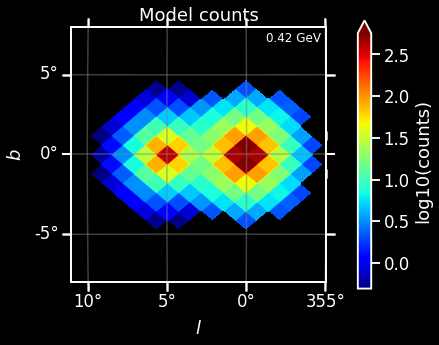

In [12]:
df = PSFlist.demo_df() 
source_model = sl.SourceModel.demo(3)
band = Band(df.iloc[2], source_model)
show(band)
band.plot_pixel_map((3,0),log=True, data=band.pixel_counts(), size=16, title='Model counts')

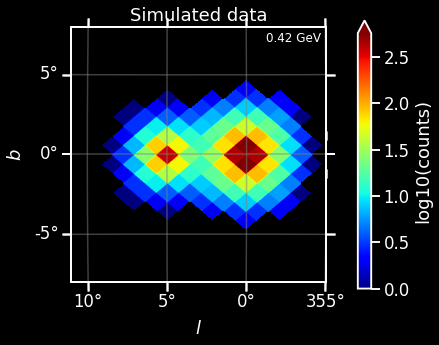

In [13]:
band.data = band.simulate()
band.plot_pixel_map((3,0), log=True, size=16, data=band.data, title='Simulated data')

### Loglike surface around each source position

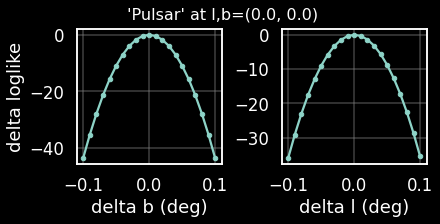

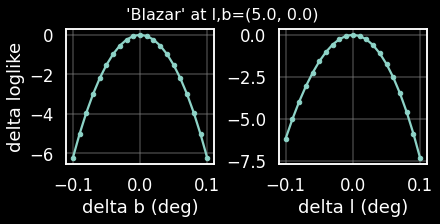

In [14]:
show(f"""### Loglike surface around each source position""")
for src in source_model: 
 
    l0, b0 = src.skydir.l.deg, src.skydir.b.deg
    llz = band.loglike()
    delta = np.linspace(-.1,.1, 21)        

    with source_model.localization_context(src.name):
     
        sll = SkyCoord(l0 + delta, b0, unit='deg', frame='galactic')
        sbb = SkyCoord(l0, b0 + delta, unit='deg', frame='galactic')
        
        yll = [band.loglike(x)-llz  for x in sll]
        ybb = [band.loglike(x)-llz  for x in sbb]

    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6,3),)# sharey=True)

    ax1.plot(delta, ybb, '.-');
    ax2.plot(delta, yll, '.-');
    ax1.set(xlabel='delta b (deg)', ylabel='delta loglike', )#ylim=(-9,0.5))
    ax2.set_xlabel('delta l (deg)')
    fig.suptitle(f" '{src.name}' at l,b=({l0}, {b0})", fontsize=16);

In [15]:
from like3 import quadform; reload(quadform)
from like3.quadform import QuadForm, tests
tests()
# qf = QuadForm(sbb.deg, [loglike(self, PointSource(name='', skydir=skydir, model=test.model))-z0 for skydir in s

testing with quad pars= [1, 0, 2.0, 0, 1, 0]
fit chisq, check:      7e-30      8e-31
elliptical pars:      1.123     0.673    -1.178     0.000    -0.000    -0.000
compare two functions:      3e-30
testing with quad pars= [2, 0, 1.0, 0, 1, 0]
fit chisq, check:      7e-30      8e-31
elliptical pars:      1.123     0.673    -0.393    -0.000     0.000     0.000
compare two functions:      1e-29
testing with quad pars= [1, 1, 1, 1, 1, 1]
fit chisq, check:      3e-30      9e-30
elliptical pars:      1.414     0.816    -0.785    -0.333    -0.333     0.667
compare two functions:      4e-30
testing with quad pars= [9.0, 0, 9.0, 0, 0, 0]
fit chisq, check:      3e-29      3e-30
elliptical pars:      0.333     0.333    -0.785    -0.000     0.000    -0.000
compare two functions:      2e-29


In [16]:
sd = SourceModel.demo()
for s in sd:
    show(s)

Model: SourceModel: 2 sources with 4 free parameters


like3.sources.PointSource: 
	name  : Pulsar
	icrs  : (266.405, -28.936)
	model : PLSuperExpCutoff4
		Norm      : 1e-11 
		Index     : 2 
		Curvature : 0.7 (FROZEN)
		b         : 0.69 (FROZEN)

like3.sources.PointSource: 
	name  : Blazar
	icrs  : (269.269, -24.638)
	model : LogParabola
		Norm      : 4e-12 
		Index     : 2 
		beta      : 0 (FROZEN)
		E_break   : 1e+03 (FROZEN)

In [17]:
g = band.pixel_gradient(band.data)
g.shape

(109, 4)

## Spectral fitting
Needs multiple bands, of course

### Create a Demosource_model with a pulsar and/or a blazar 

Model: SourceModel: 2 sources with 5 free parameters 12 pixels


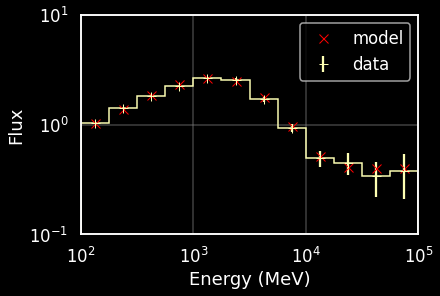

### Use Likelihood framework to fit the model to the data

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x72fcd03513f0>

AttributeError: 'Likelihood' object has no attribute 'counts'

In [ ]:
show(f"""### Create a Demosource_model with a pulsar and/or a blazar """)
from like3 import likelihood as lk; reload(lk)
from like3 import demo_model as dm; reload(dm)
model = dm.DemoModel.test(plot=True, src_key=2, random_state=42)

show(f""" ### Use Likelihood framework to fit the model to the data""")
with capture_hide('Fit summary') as cap:
    model = lk.Likelihood(model=model, data=model.data)
    print(model.model[0].model)
    model.maximize()
    model.summary()
    print(model.model[0].model)
show(cap)
# print('Previous one bin per band:', model.counts().astype(int))
